# Ensemble Time Series Forecasting
## Combining Heterogeneous Forecasters with `omnicast`

Ensemble forecasting combines predictions from multiple individual models to create a single, more robust prediction. By combining diverse statistical models (such as ARIMA, Exponential Smoothing, Theta, and baseline forecasters), an ensemble hedges against model misspecification and reduces forecast error variance.

This notebook demonstrates:
1. **Equal-Weighted Ensembles (Default)**: Giving the same weight to all selected forecasters ($1/N$).
2. **Custom-Weighted Ensembles**: Specifying weights via lists, arrays, or dictionaries.
3. **Automated Ensembling with `AutoForecaster`**: Turning backtest-evaluated candidates directly into an ensemble.
4. **Prediction Intervals**: Calibrating uncertainty using total mixture variance (combining intra-model and inter-model variance).
5. **Backtesting & Evaluation**: Benchmarking the ensemble against individual component models.


In [1]:
import sys
from pathlib import Path

# Ensure omnicast is discoverable regardless of kernel or working directory
for parent in [Path.cwd(), Path.cwd().parent, *Path.cwd().parents]:
    src_path = parent / "src"
    if (src_path / "omnicast").is_dir():
        if str(src_path) not in sys.path:
            sys.path.insert(0, str(src_path))
        break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from omnicast import (
    AutoForecaster,
    EnsembleForecaster,
    backtest,
)
from omnicast.models import (
    ARIMAForecaster,
    DriftForecaster,
    ETSForecaster,
    NaiveForecaster,
    ThetaForecaster,
)

# Set visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 1. Preparing Sample Time-Series Data

We generate a reproducible monthly time series spanning four years (48 observations) exhibiting both an upward trend and yearly seasonality.


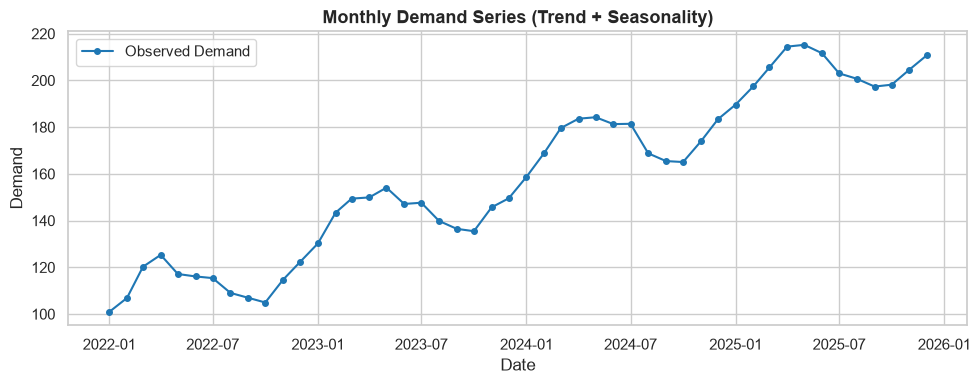

2025-08    200.70
2025-09    197.36
2025-10    198.16
2025-11    204.62
2025-12    210.67
Freq: M, Name: monthly_demand, dtype: float64

In [2]:
rng = np.random.default_rng(42)
n_periods = 48
t = np.arange(n_periods)
trend = 100 + 2.5 * t
season = 15 * np.sin(2 * np.pi * t / 12)
noise = rng.normal(0, 3, size=n_periods)

y = pd.Series(
    (trend + season + noise).round(2),
    index=pd.period_range("2022-01", periods=n_periods, freq="M"),
    name="monthly_demand",
)

plt.figure(figsize=(10, 4))
plt.plot(y.index.to_timestamp(), y.values, marker="o", markersize=4, color="#1f77b4", label="Observed Demand")
plt.title("Monthly Demand Series (Trend + Seasonality)", fontsize=13, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

y.tail()


## 2. Equal-Weighted Ensemble (Default Behavior)

By default, `EnsembleForecaster` gives the exact same weight to all selected models ($w_i = 1 / N$).

Here, we combine four distinct forecasters:
- `ThetaForecaster` (dynamic seasonal-adjusted decomposition)
- `ETSForecaster` (exponential smoothing)
- `ARIMAForecaster` (autoregressive integrated moving average)
- `DriftForecaster` (linear trajectory extrapolation)


In [3]:
# Initialize EnsembleForecaster without weights (defaults to equal weighting)
equal_ensemble = EnsembleForecaster(
    models=[
        ThetaForecaster(seasonal_period=12),
        ETSForecaster(),
        ARIMAForecaster(order=(1, 1, 0)),
        DriftForecaster(),
    ]
)
equal_ensemble.fit(y)

print(f"Fitted models in ensemble: {len(equal_ensemble.fitted_models_)}")
print("Model Weights (Equal):")
for name, weight in equal_ensemble.weights_dict_.items():
    print(f"  {name:22s} : {weight:.4f}")


Fitted models in ensemble: 4
Model Weights (Equal):
  ThetaForecaster        : 0.2500
  ETSForecaster          : 0.2500
  ARIMAForecaster        : 0.2500
  DriftForecaster        : 0.2500


### Forecasting with Uncertainty Intervals

When generating forecasts, `EnsembleForecaster` computes:
1. **Point forecasts**: $\mu_{\text{ens}} = \sum w_i \mu_i$
2. **Prediction intervals**: Combining within-model error variance and inter-model disagreement variance:
   $$\text{Var}_{\text{ens}} = \sum w_i \sigma_i^2 + \sum w_i (\mu_i - \mu_{\text{ens}})^2$$


In [4]:
# Generate a 12-month ahead forecast with 80% and 95% intervals
forecast_equal = equal_ensemble.predict(horizon=12, level=[80, 95])
forecast_equal.to_frame()


,mean,lower_80,upper_80,lower_95,upper_95
2026-01,216.193668,208.374501,224.012836,204.235283,228.152054
2026-02,221.893922,207.105632,236.682213,199.277183,244.510661
2026-03,227.615638,204.905556,250.325720,192.883565,262.347711
2026-04,230.999628,202.344793,259.654463,187.175840,274.823416
2026-05,232.108245,198.258552,265.957938,180.339606,283.876884
2026-06,232.444615,191.883037,273.006194,170.411034,294.478196
2026-07,233.517820,184.812826,282.222813,159.029959,308.005680
2026-08,232.498280,174.137533,290.859027,143.243220,321.753340
2026-09,233.164979,164.840360,301.489599,128.671491,337.658468
2026-10,234.629165,156.290555,312.967774,114.820601,354.437729


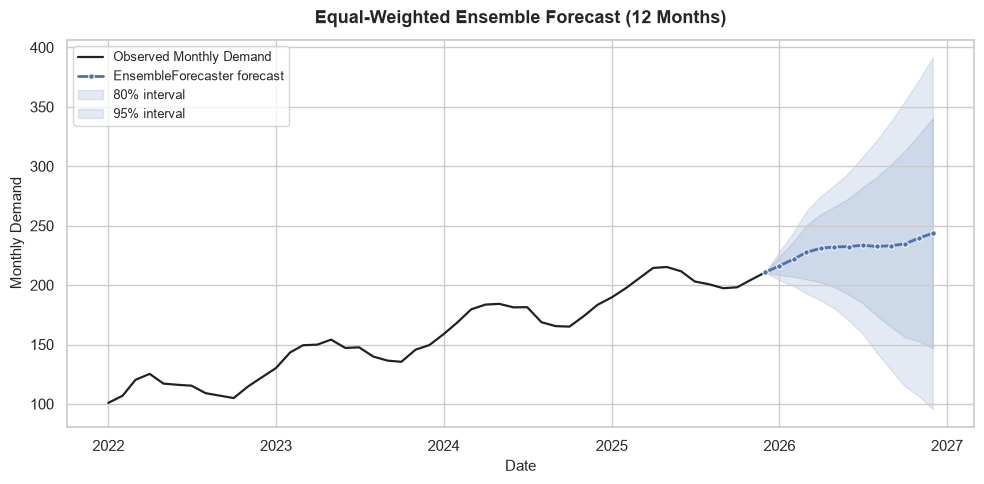

In [5]:
# Plot the ensemble forecast and its prediction bands
ax = forecast_equal.plot(title="Equal-Weighted Ensemble Forecast (12 Months)")
plt.show()


## 3. Custom-Weighted Ensemble Forecaster

`EnsembleForecaster` accepts a `weights` parameter to specify custom weighting schemes. Weights can be supplied as:
- A sequence of numbers (e.g., list or numpy array)
- A dictionary mapping model class names to weights

All weights are automatically validated and normalized to sum to 1.0.


In [6]:
# Option A: List of weights (e.g. favoring Theta and ETS)
weights_list = [0.4, 0.4, 0.15, 0.05]

weighted_ensemble_list = EnsembleForecaster(
    models=[
        ThetaForecaster(seasonal_period=12),
        ETSForecaster(),
        ARIMAForecaster(order=(1, 1, 0)),
        DriftForecaster(),
    ],
    weights=weights_list,
).fit(y)

print("Custom weights (list):")
for name, weight in weighted_ensemble_list.weights_dict_.items():
    print(f"  {name:22s} : {weight:.4f}")


Custom weights (list):
  ThetaForecaster        : 0.4000
  ETSForecaster          : 0.4000
  ARIMAForecaster        : 0.1500
  DriftForecaster        : 0.0500


In [7]:
# Option B: Dictionary of weights by model name
weights_dict = {
    "ThetaForecaster": 0.50,
    "ETSForecaster": 0.30,
    "ARIMAForecaster": 0.20,
    "DriftForecaster": 0.00,
}

weighted_ensemble_dict = EnsembleForecaster(
    models=[
        ThetaForecaster(seasonal_period=12),
        ETSForecaster(),
        ARIMAForecaster(order=(1, 1, 0)),
        DriftForecaster(),
    ],
    weights=weights_dict,
).fit(y)

print("Custom weights (dict):")
for name, weight in weighted_ensemble_dict.weights_dict_.items():
    print(f"  {name:22s} : {weight:.4f}")


Custom weights (dict):
  ThetaForecaster        : 0.5000
  ETSForecaster          : 0.3000
  ARIMAForecaster        : 0.2000
  DriftForecaster        : 0.0000


### Visualizing Individual Components vs. Ensemble

The `plot_components()` helper overlays every constituent model's trajectory alongside the combined ensemble forecast.


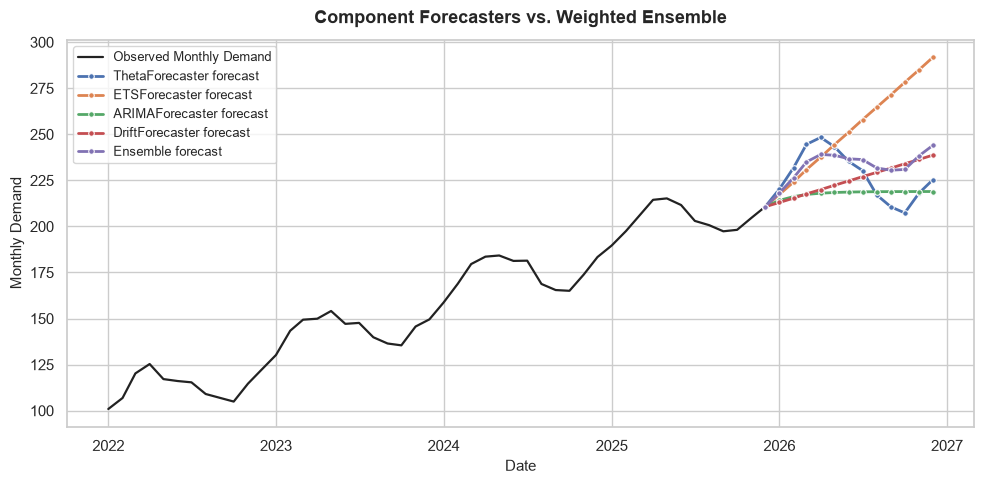

In [8]:
weighted_ensemble_dict.plot_components(
    horizon=12,
    title="Component Forecasters vs. Weighted Ensemble",
)
plt.show()


## 4. Automated Candidate Selection & Ensembling with `AutoForecaster`

`AutoForecaster` evaluates a panel of candidate models via rolling-origin backtesting. Rather than choosing only a single winner, you can turn the evaluated candidates directly into an ensemble via `.ensemble()`:

- `auto.ensemble()`: Creates an equal-weighted ensemble of all successful candidates.
- `auto.ensemble(top_k=K)`: Ensembles only the top $K$ models from the leaderboard.
- `auto.ensemble(weights=...)`: Ensembles candidates with custom weights.
- `auto.predict_ensemble(horizon=...)`: Directly generates the ensemble forecast.


In [9]:
# Backtest candidates on historical folds
auto = AutoForecaster(
    models=[
        NaiveForecaster(),
        DriftForecaster(),
        ThetaForecaster(seasonal_period=12),
        ETSForecaster(),
    ],
    metric="rmse",
    validation_horizon=3,
    keep_all=True,
).fit(y)

print("AutoForecaster Leaderboard:")
display_df = auto.leaderboard_.copy()
display_df["score"] = display_df["score"].round(3)
display_df


AutoForecaster Leaderboard:


,model,score,status
0,ThetaForecaster,7.247,ok
1,NaiveForecaster,10.252,ok
2,DriftForecaster,10.347,ok
3,ETSForecaster,10.813,ok


Top-2 Auto Ensemble Weights:
  NaiveForecaster          : 0.5000
  ThetaForecaster          : 0.5000


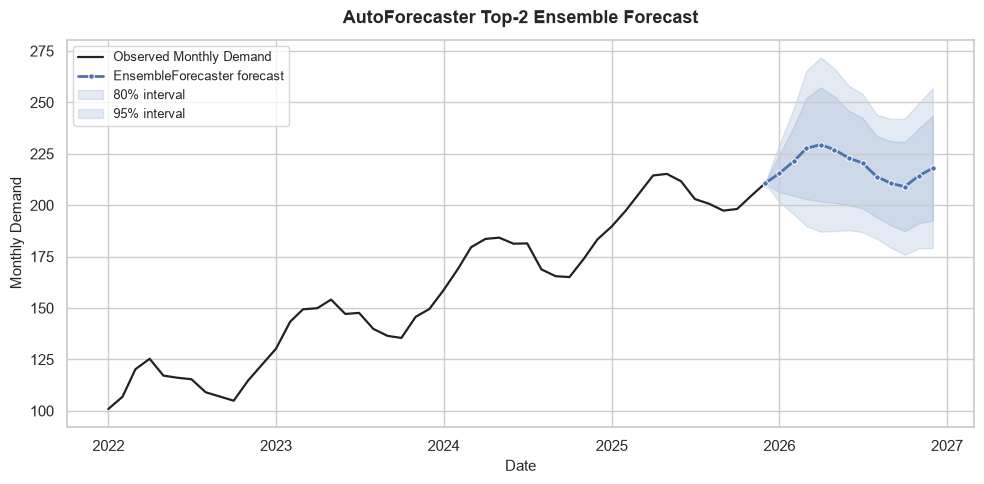

In [10]:
# Create an ensemble of the top 2 performing models
auto_ensemble_top2 = auto.ensemble(top_k=2)

print("Top-2 Auto Ensemble Weights:")
for name, weight in auto_ensemble_top2.weights_dict_.items():
    print(f"  {name:24s} : {weight:.4f}")

# Forecast directly with predict_ensemble
pred_auto_ens = auto.predict_ensemble(horizon=12, top_k=2)
ax = pred_auto_ens.plot(title="AutoForecaster Top-2 Ensemble Forecast")
plt.show()


## 5. Backtesting & Empirical Performance Comparison

We can compare out-of-sample backtest scores between individual models and the ensemble across multiple rolling-origin folds using `backtest`.


In [11]:
horizon = 3
initial = len(y) - 12  # Last 12 months for rolling validation

models_to_evaluate = {
    "Naive Baseline": NaiveForecaster(),
    "Drift": DriftForecaster(),
    "ETS": ETSForecaster(),
    "Theta": ThetaForecaster(seasonal_period=12),
    "ARIMA(1,1,0)": ARIMAForecaster(order=(1, 1, 0)),
    "Equal Ensemble": EnsembleForecaster(
        models=[
            ThetaForecaster(seasonal_period=12),
            ETSForecaster(),
            ARIMAForecaster(order=(1, 1, 0)),
            DriftForecaster(),
        ]
    ),
    "Weighted Ensemble": EnsembleForecaster(
        models=[
            ThetaForecaster(seasonal_period=12),
            ETSForecaster(),
            ARIMAForecaster(order=(1, 1, 0)),
            DriftForecaster(),
        ],
        weights=[0.4, 0.4, 0.15, 0.05],
    ),
}

scores = []
for name, model in models_to_evaluate.items():
    res = backtest(model, y, horizon=horizon, initial=initial, metric="rmse")
    mean_rmse = res.summary()["mean"]
    std_rmse = res.summary()["std"]
    scores.append({"Model": name, "Mean RMSE": round(mean_rmse, 3), "Std RMSE": round(std_rmse, 3)})

comparison_df = pd.DataFrame(scores).sort_values("Mean RMSE").reset_index(drop=True)
comparison_df


,Model,Mean RMSE,Std RMSE
0,Weighted Ensemble,6.105,3.555
1,Equal Ensemble,6.109,3.422
2,Theta,7.247,2.878
3,"ARIMA(1,1,0)",8.592,4.024
4,Naive Baseline,10.252,4.771
5,Drift,10.347,4.722
6,ETS,10.813,7.318


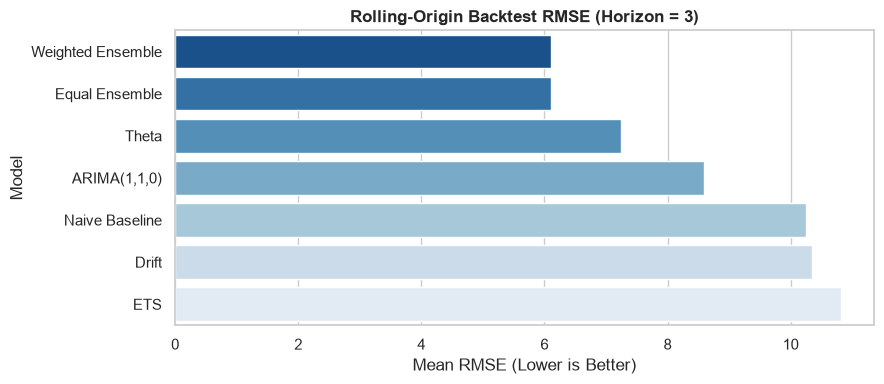

In [12]:
plt.figure(figsize=(9, 4))
sns.barplot(data=comparison_df, x="Mean RMSE", y="Model", hue="Model", legend=False, palette="Blues_r")
plt.title(f"Rolling-Origin Backtest RMSE (Horizon = {horizon})", fontsize=12, fontweight="bold")
plt.xlabel("Mean RMSE (Lower is Better)")
plt.tight_layout()
plt.show()


## Conclusion

- `EnsembleForecaster` provides an intuitive, robust interface for combining forecasts with equal weights by default or custom weights.
- Mixture-variance calculation provides well-calibrated prediction intervals that reflect both individual model error and model disagreement.
- Integration with `AutoForecaster` allows effortless ensembling of the best candidate models discovered during automated search.
